In [1]:
import tensorflow as tf
from keras.optimizers import Adam
from keras import Sequential
from keras.layers import Dense
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

part1
electric.csv
1. law, 케라스학습
2. scatter 와 예측선
3. 전기 생산량 4, 5인 경우 전기 사용량 예측
4. 결정계수(sklearn이용)

In [2]:
elec = pd.read_csv('../data/electric.csv', index_col='Unnamed: 0')
elec.head()

,전기생산량,전기사용량
0,3.52,2.48
1,2.58,2.27
2,3.31,2.47
3,4.07,2.77
4,4.62,2.98


In [3]:
x = elec['전기생산량'].values
y = elec['전기사용량'].values

In [4]:
w = tf.Variable( 10.0, dtype=tf.float32 )
b = tf.Variable( 10.0, dtype=tf.float32)

lr = 0.01
optimizer = tf.keras.optimizers.Adam(learning_rate = lr)
for i in range(2000):
    with tf.GradientTape() as tape :
        hx = w * x + b
        cost = tf.reduce_mean((hx-y)**2)
    
    gradients = tape.gradient( cost, [w, b] )
    optimizer.apply_gradients( zip(gradients,[w,b]) )
    print('cost : ', cost.numpy())

print('최종 w : ', w.numpy(), '최종 b : ', b.numpy())

cost :  2152.8677
cost :  2148.2988
cost :  2143.735
cost :  2139.1765
cost :  2134.623
cost :  2130.0747
cost :  2125.532
cost :  2120.9941
cost :  2116.4617
cost :  2111.9353
cost :  2107.4143
cost :  2102.899
cost :  2098.3894
cost :  2093.8857
cost :  2089.3877
cost :  2084.8958
cost :  2080.41
cost :  2075.9304
cost :  2071.4565
cost :  2066.989
cost :  2062.5278
cost :  2058.0732
cost :  2053.6243
cost :  2049.1826
cost :  2044.7472
cost :  2040.3185
cost :  2035.8959
cost :  2031.4801
cost :  2027.0707
cost :  2022.6678
cost :  2018.2716
cost :  2013.8822
cost :  2009.4994
cost :  2005.1237
cost :  2000.7544
cost :  1996.3917
cost :  1992.0361
cost :  1987.6875
cost :  1983.3456
cost :  1979.0104
cost :  1974.6821
cost :  1970.3607
cost :  1966.0463
cost :  1961.7388
cost :  1957.4381
cost :  1953.1444
cost :  1948.8578
cost :  1944.578
cost :  1940.305
cost :  1936.0391
cost :  1931.7799
cost :  1927.5277
cost :  1923.2822
cost :  1919.044
cost :  1914.8125
cost :  1910.5879
co

In [5]:
def predFn( xd):
    hx = w * xd + b
    return hx.numpy()

predFn([4,5])

array([3.568921, 4.281712], dtype=float32)

In [7]:
dense = Dense(units=1, input_dim=1)
model = Sequential([dense])
model.compile(loss='mse', optimizer=Adam(0.1))
h = model.fit(x,y, epochs=500)

Epoch 1/500


c:\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - loss: 35.7972
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 30.1476
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 24.9988
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 20.3576
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 16.2276
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 12.6079
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 9.4934
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 6.8730
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 4.7295
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 3.0390
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.7700
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.8837
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.3347
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0715
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0384
Epoch 16/500
1/1 ━━━━━━━

In [9]:
y_pred = model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


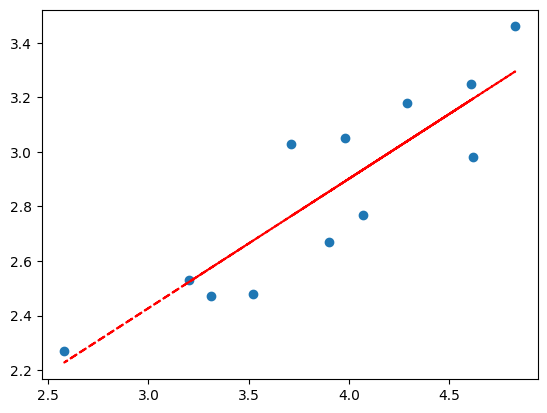

In [10]:
plt.scatter(x,y)
plt.plot(x,y_pred,'r--')
plt.show()

In [12]:
w,b = dense.get_weights()
print(w)
print(b)

[[0.4743435]]
[1.0039281]


In [14]:
print(model.predict(np.array([[4]])))
print(model.predict(np.array([[5]])))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[[2.901302]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[[3.3756456]]


In [31]:
r2 = r2_score(y, y_pred)
print('결정계수 : ', r2)

결정계수 :  0.8827801759580978


part2
trees.csv
1. 케라스 학습
2. 예측값과, 실제값 plot
3. 11.1, 80 인경우 volums 예측
4. 결정계수

In [18]:
tdf = pd.read_csv('../data/trees.csv')
x = tdf.iloc[:,:-1].values
y = tdf.iloc[:,-1].values

In [21]:
dense = Dense(units=1, input_dim=2)
model = Sequential([dense])
model.compile(loss='mse', optimizer=Adam(0.1))
model.fit(x,y, epochs=500)
y_pred = model.predict(x)

Epoch 1/500


c:\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 555ms/step - loss: 1304.2123
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 826.8700
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 519.2151
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 372.4724
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 358.4586
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 424.5811
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 506.9174
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 558.1532
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 562.1453
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 526.6146
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 469.7238
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 410.6026
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 364.2601
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 339.1023
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 336.1171

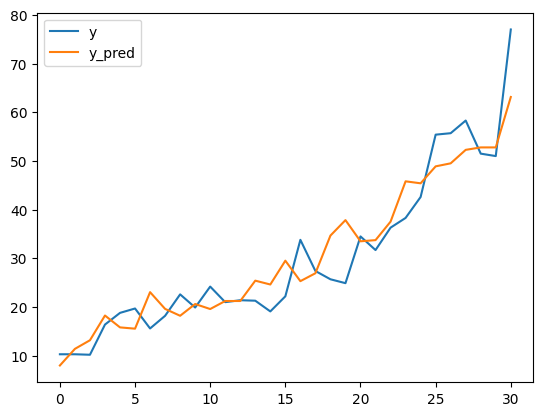

In [28]:
plt.plot(y, label='y')
plt.plot(y_pred, label='y_pred')
plt.legend()
plt.show()

In [25]:
print('volume : ', model.predict(np.array([[11.1,80]])))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
volume :  [[18.206154]]


In [26]:
r2 = r2_score(y, y_pred)
print('결정계수 : ', r2)

결정계수 :  0.8827801759580978
